In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import mne
from mne import io
#from mne.datasets import sample
from mne.minimum_norm import compute_source_psd, read_inverse_operator
from mne.minimum_norm import (make_inverse_operator, apply_inverse,
                              write_inverse_operator)

## For Data Visualisation

# For elimiating warnings
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)

import mne.viz
%matplotlib inline

import pylab, seaborn as sns
from scipy.stats import ttest_rel, sem

## Baseline Correction

import copy

In [5]:
root = ("experiments")
list_file_names = []
for path, dirs, files in os.walk(root):
    for file in files:
        if file.endswith(".bdf"):
             list_file_names.append(os.path.join(root, file))
print(len(list_file_names),'files')
#for i in list_file_names:
#    print(i[56:])

21 files


In [6]:
raw = mne.io.read_raw_bdf(list_file_names[1],preload=True)
raw
#raw.info['meas_date']
#raw.pick_types(meg=False, eeg=True, eog=False, exclude='bads')
#raw.pick_types(meg=True, eeg=True, eog=True)

Extracting EDF parameters from F:\PhD\materials_neuroscience\EEG_work\trials\experiments\ck values deu thr.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 960511  =      0.000 ...   469.000 secs...


Measurement date,"April 01, 2017 14:24:53 GMT"
Experimenter,Unknown
Participant,ck
Digitized points,Not available
Good channels,"40 EEG, 1 Stimulus"
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,2048.00 Hz
Highpass,0.00 Hz
Lowpass,417.00 Hz


In [4]:
len(raw.get_data()[0])

831488

In [48]:
# raw.set_montage('easycap-M1')
mne.channels.get_builtin_montages()

['standard_1005',
 'standard_1020',
 'standard_alphabetic',
 'standard_postfixed',
 'standard_prefixed',
 'standard_primed',
 'biosemi16',
 'biosemi32',
 'biosemi64',
 'biosemi128',
 'biosemi160',
 'biosemi256',
 'easycap-M1',
 'easycap-M10',
 'easycap-M43',
 'EGI_256',
 'GSN-HydroCel-32',
 'GSN-HydroCel-64_1.0',
 'GSN-HydroCel-65_1.0',
 'GSN-HydroCel-128',
 'GSN-HydroCel-129',
 'GSN-HydroCel-256',
 'GSN-HydroCel-257',
 'mgh60',
 'mgh70',
 'artinis-octamon',
 'artinis-brite23',
 'brainproducts-RNP-BA-128']

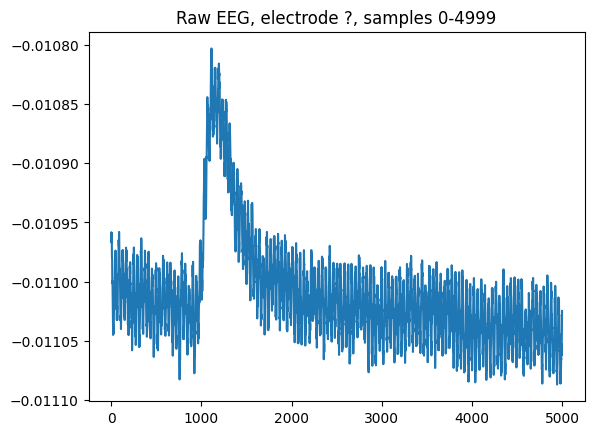

In [5]:
plt.plot(raw._data[0,:4999]) # raw._data == raw.get_data()
plt.title("Raw EEG, electrode ?, samples 0-4999")
plt.show()

In [9]:
#Extract events from raw data
raw.info['bads'] = ['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8',]
events = mne.find_events(raw, stim_channel=raw.info['ch_names'],initial_event=False)
events # [event time in samples , ? , event_ids]

Trigger channel Status has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
242 events found on stim channel Status
Event IDs: [  1   2   4   8   9  10  16  32  64 128]


array([[255263,      0,    128],
       [257203,      0,      1],
       [260581,      0,      2],
       [263481,      0,      4],
       [266006,      0,      8],
       [267764,      0,     16],
       [267814,      0,      9],
       [269520,      0,      1],
       [272898,      0,      2],
       [275798,      0,      4],
       [278016,      0,      8],
       [287736,      0,     64],
       [289685,      0,      1],
       [293063,      0,      2],
       [295964,      0,      4],
       [298181,      0,      8],
       [307069,      0,     64],
       [307121,      0,      9],
       [308929,      0,      1],
       [312307,      0,      2],
       [315207,      0,      4],
       [317732,      0,      8],
       [320454,      0,     16],
       [321588,      0,      1],
       [324966,      0,      2],
       [327866,      0,      4],
       [329981,      0,      8],
       [330792,      0,     16],
       [332848,      0,      1],
       [336225,      0,      2],
       [33

In [7]:
len(events)

246

In [8]:
raw.info['ch_names'];

In [9]:
tmin, tmax = -0.2, 0.5  # define epochs around events (in s)
#event_ids = dict(hands=2, feet=3)  # map event IDs to tasks
event_ids = sorted(list(set([item[2] for item in events])))

epochs = mne.Epochs(raw, events, event_ids, tmin - 0.5, tmax + 0.5, baseline=None, preload=True)

Not setting metadata
246 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 246 events and 3483 original time points ...
1 bad epochs dropped


In [10]:
epochs

Number of events,245
Events,1: 4110: 17128: 616: 182: 4125: 132: 74: 4164: 1565536: 073: 18: 419: 16
Time range,-0.700 – 1.000 s
Baseline,off


In [11]:
#Access to the data
data = epochs._data

n_events = len(data) # or len(epochs.events)
print("Number of events: " + str(n_events)) 

n_channels = len(data[0,:]) # or len(epochs.ch_names)
print("Number of channels: " + str(n_channels))

n_times = len(data[0,0,:]) # or len(epochs.times)
print("Number of time instances: " + str(n_times))

Number of events: 245
Number of channels: 41
Number of time instances: 3483


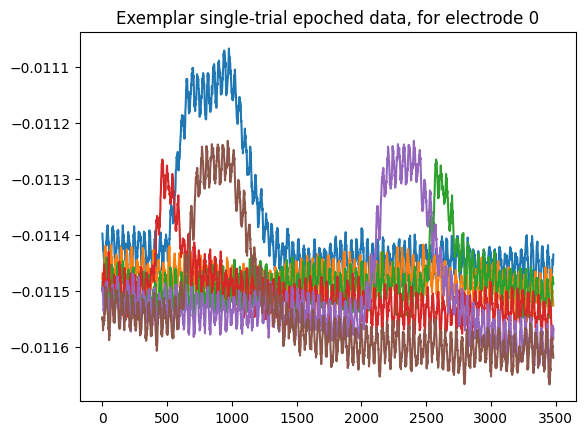

In [12]:
plt.plot(data[14:20,0,:].T)
plt.title("Exemplar single-trial epoched data, for electrode 0")
plt.show()

In [13]:
epochs.average()

Condition,0.17 × 1 + 0.17 × 2 + 0.17 × 4 + 0.17 × 8 + 0.07 × 9 + 0.07 × 10 + 0.07 × 16 + 0.00 × 25 + 0.03 × 32 + 0.06 × 64 + 0.00 × 73 + 0.02 × 128 + 0.00 × 65536
Data kind,average
Timepoints,3483 samples
Channels,40 channels
Number of averaged epochs,245
Time range (secs),-0.7001953125 – 1.0
Baseline (secs),off


In [14]:
evoked = epochs.average()
evoked_data = evoked.data
n_channels = len(evoked_data) # or len(evoked.ch_names)
print("Number of channels: " + str(n_channels))

n_times = len(evoked_data[0,:]) # or len(evoked.times)
print("Number of time instances: " + str(n_times))

Number of channels: 40
Number of time instances: 3483


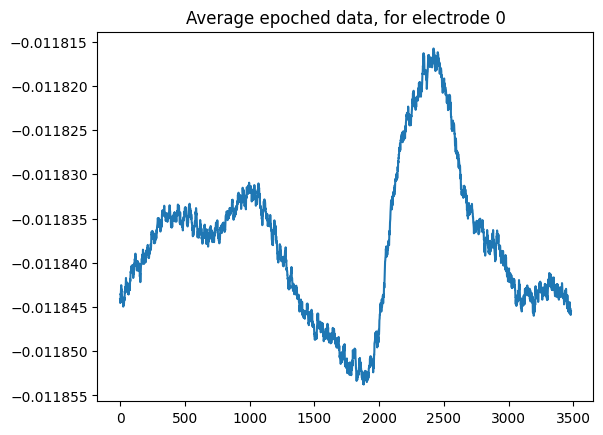

In [15]:
# Compared to the single-trial epochs, the averaged ones are much smoother:
plt.plot(evoked._data[0,:].T)
plt.title("Average epoched data, for electrode 0")
plt.show()

# Data Visualisation

Using matplotlib as 2D backend.


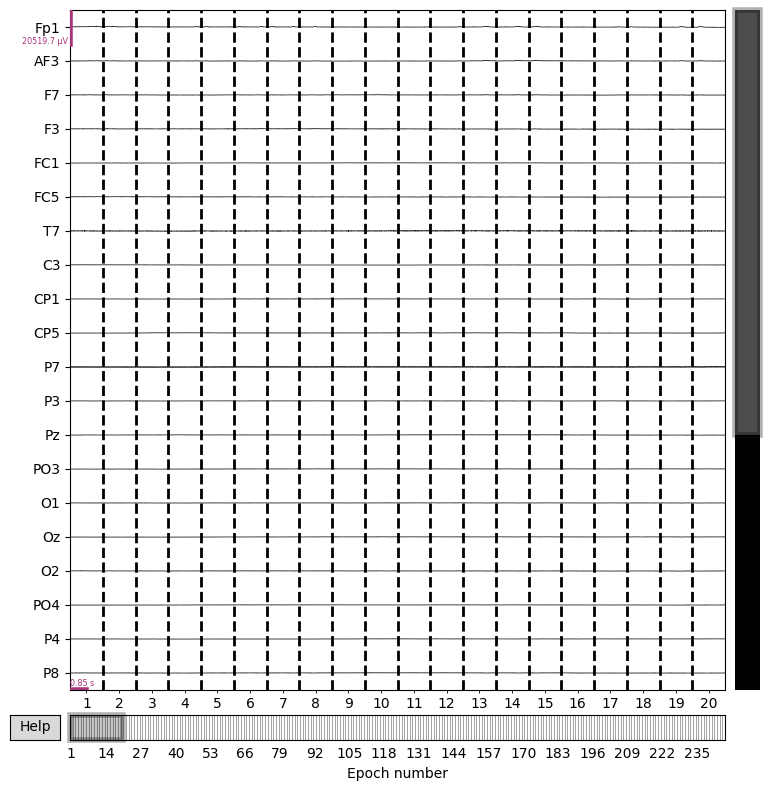

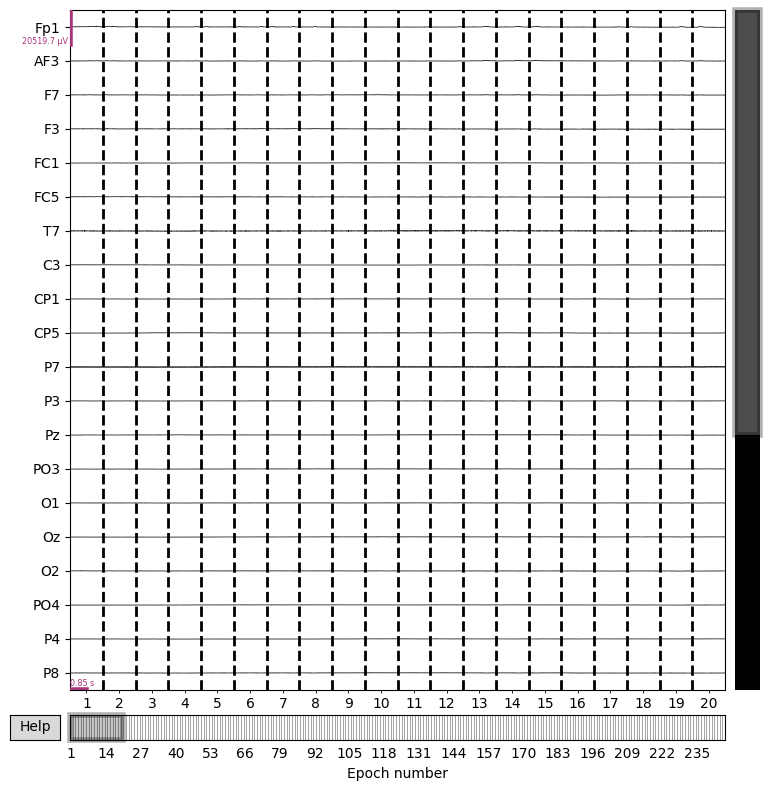

In [16]:
#%matplotlib tk
#%matplotlib widget

#epochs = epochs['32','64','128']
#print('Percentage of Pleasant familiar events : ', np.around(len(epochs['128'])/len(epochs), decimals=2))
#print('Percentage of Neutral familiar events : ',np.around(len(epochs['64'])/len(epochs), decimals=2))
#print('Percentage of Unpleasant familiar : ', np.around(len(epochs['32'])/len(epochs), decimals=2))
epochs.plot(scalings='auto')

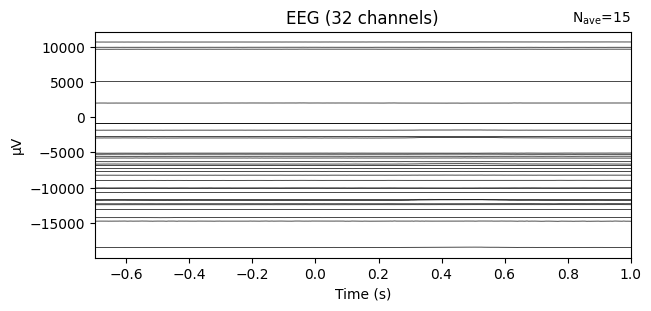

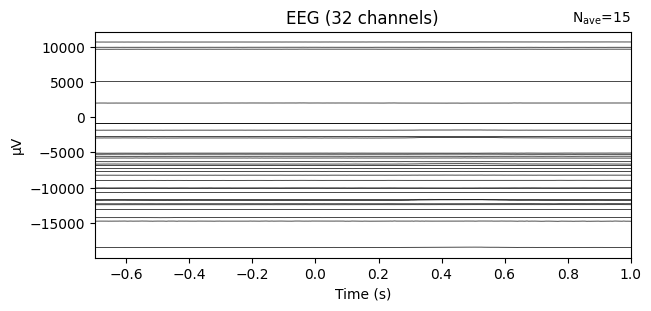

In [17]:
epochs['64'].average().plot()

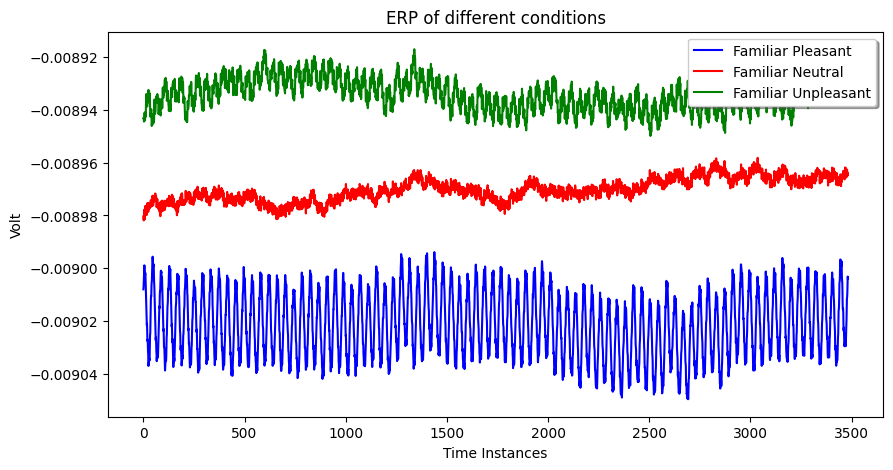

In [18]:
#%matplotlib inline

fp = epochs['32']
fn = epochs['64']
fu = epochs['128']
ch = 18
conditions = ['FP', 'FN', 'FU']

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel('Time Instances')
ax.set_ylabel('Volt')

ax.plot(fp.average().data[ch, :], color='blue', label='Familiar Pleasant')
ax.plot(fn.average().data[ch, :], color='red', label='Familiar Neutral')
ax.plot(fu.average().data[ch, :], color='green', label='Familiar Unpleasant')

legend = ax.legend(loc='upper right', shadow=True, fontsize='medium')
plt.title('ERP of different conditions')
plt.show()

In [19]:
## Plotting topographic information 

#%matplotlib inline
#times = np.arange(0, 1, 0.1)
#epochs.average().plot_topomap(times, ch_type='eeg')

In [20]:
def plot_conditions(data, times, plot_title):

    sns.set(style="white")
    ColorsL = np.array(([228,26,28], [55,126,184], [77,175,74], [152,78,163], [255,127,0]))/256
    col_axes = np.array((82, 82, 82))/256

    al = 0.2
    fig = plt.figure(num=None, figsize=(4, 2), dpi=150)

    
    epochs_mean = np.mean(data, axis = 0)
    epochs_std = sem(data, axis = 0)/2

    plt.plot(times, epochs_mean, color = ColorsL[0], linewidth = 2)
    plt.fill_between(times, epochs_mean, epochs_mean + epochs_std, color = ColorsL[0], interpolate=True, alpha = al)
    plt.fill_between(times, epochs_mean, epochs_mean - epochs_std, color = ColorsL[0], interpolate=True, alpha = al)
    plt.ylabel('Mean ERP')
    plt.xlabel('Times')
    plt.title(plot_title)

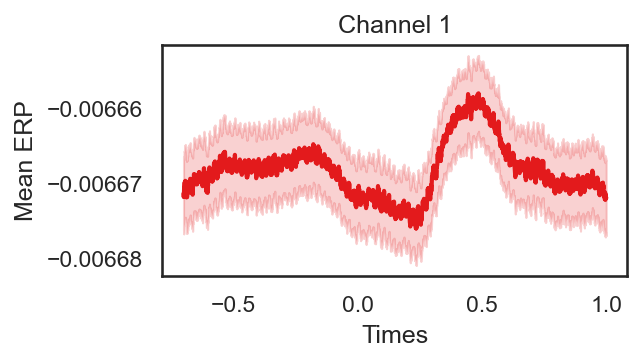

In [21]:
plot_conditions(epochs.get_data()[:,1,:], epochs.times, 'Channel 1')

## Baseline Correction

In [22]:
# The traditional way is subtracting the mean of a baseline period from every time point of the baseline and post-stimulus interval. 
# In other words, the average voltage values of each electrode are calculated within a time interval and then this average is substracted from that time interval of the signal.

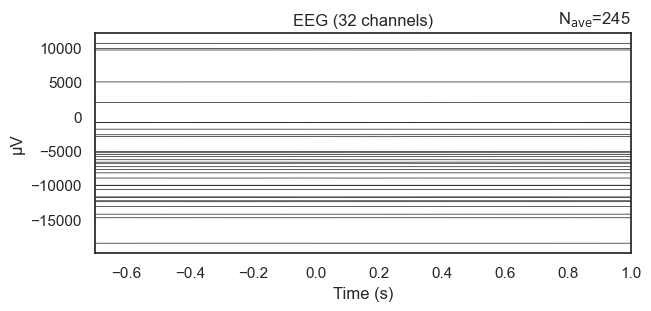

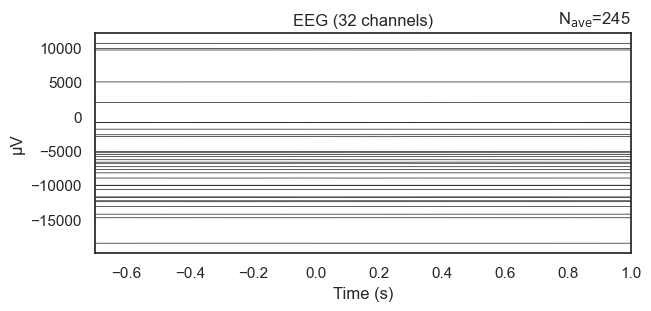

In [23]:
# Plot of initial evoked object
epochs.average().plot()

Applying baseline correction (mode: mean)


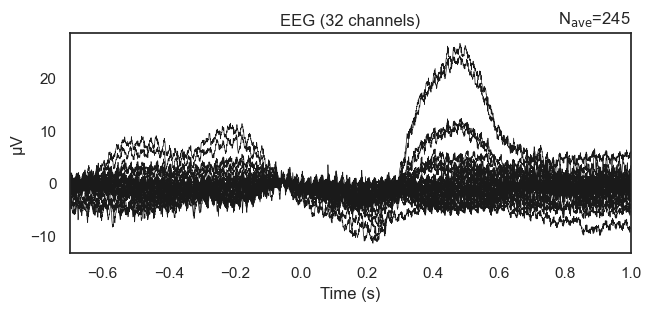

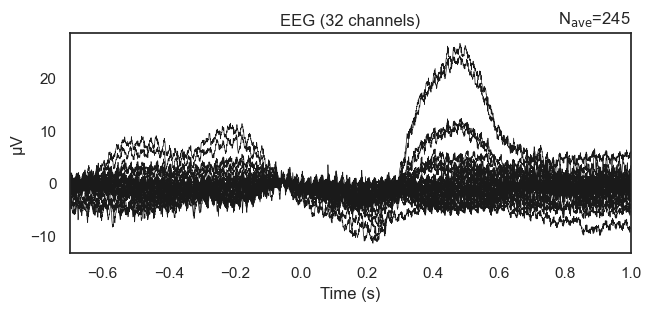

In [25]:
epochs_wo_bc = copy.deepcopy(epochs)
# baseline correction
inteval = (-0.1, 0)
bc_epochs = epochs.apply_baseline(inteval)

# Plot of baseline-corrected evoked signal
bc_epochs.average().plot()

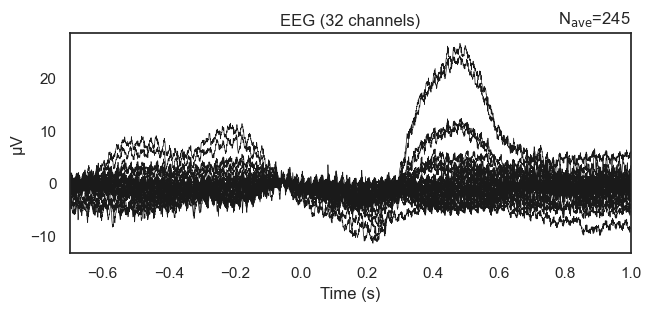

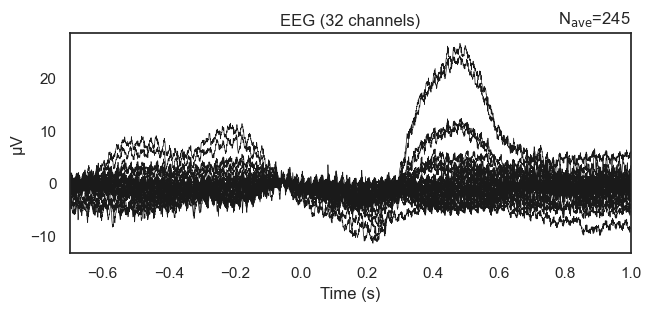

In [26]:
#Modified evoked object
epochs.average().plot()

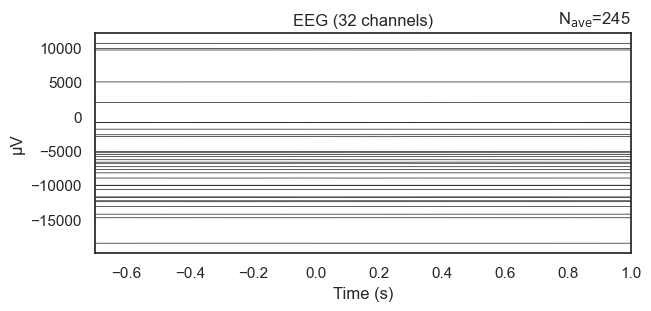

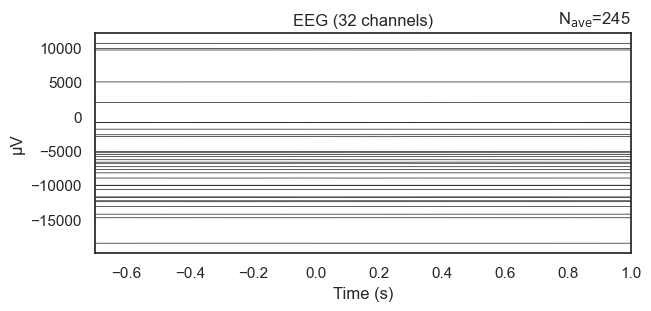

In [27]:
epochs_wo_bc.average().plot()

In [28]:
def plotChannel(ch_index, with_baselineCorrection, without_baselineCorrection):

    ch = ch_index 
    data_types = ['original', 'bc']

    for i in range(len(data_types)):

        fig, ax = plt.subplots(figsize=(20, 10))
        ax.set_xlabel('Time instances')
        ax.set_ylabel('Volt')
        #plt.ylim(-1.1, 1.5) 
        if data_types[i] == 'bc': 
            plt.title('Plot of Single Trials with Baseline Correction')
            for i in range(len(with_baselineCorrection.get_data())):   
                ax.plot(with_baselineCorrection.times, with_baselineCorrection.get_data()[i,ch,:])
            ax.plot(with_baselineCorrection.average().times, with_baselineCorrection.average().data[ch,:], color='black', label='Average of Trials')

        else:
            plt.title('Plot of Single Trials without Baseline Correction')
            for i in range(len(without_baselineCorrection.get_data())):   
                ax.plot(without_baselineCorrection.times, without_baselineCorrection.get_data()[i,ch,:])
            ax.plot(without_baselineCorrection.average().times, without_baselineCorrection.average().data[ch,:], color='black', label='Average of Trials')

        legend = ax.legend(loc='upper center', shadow=True, fontsize='large')
        plt.show()

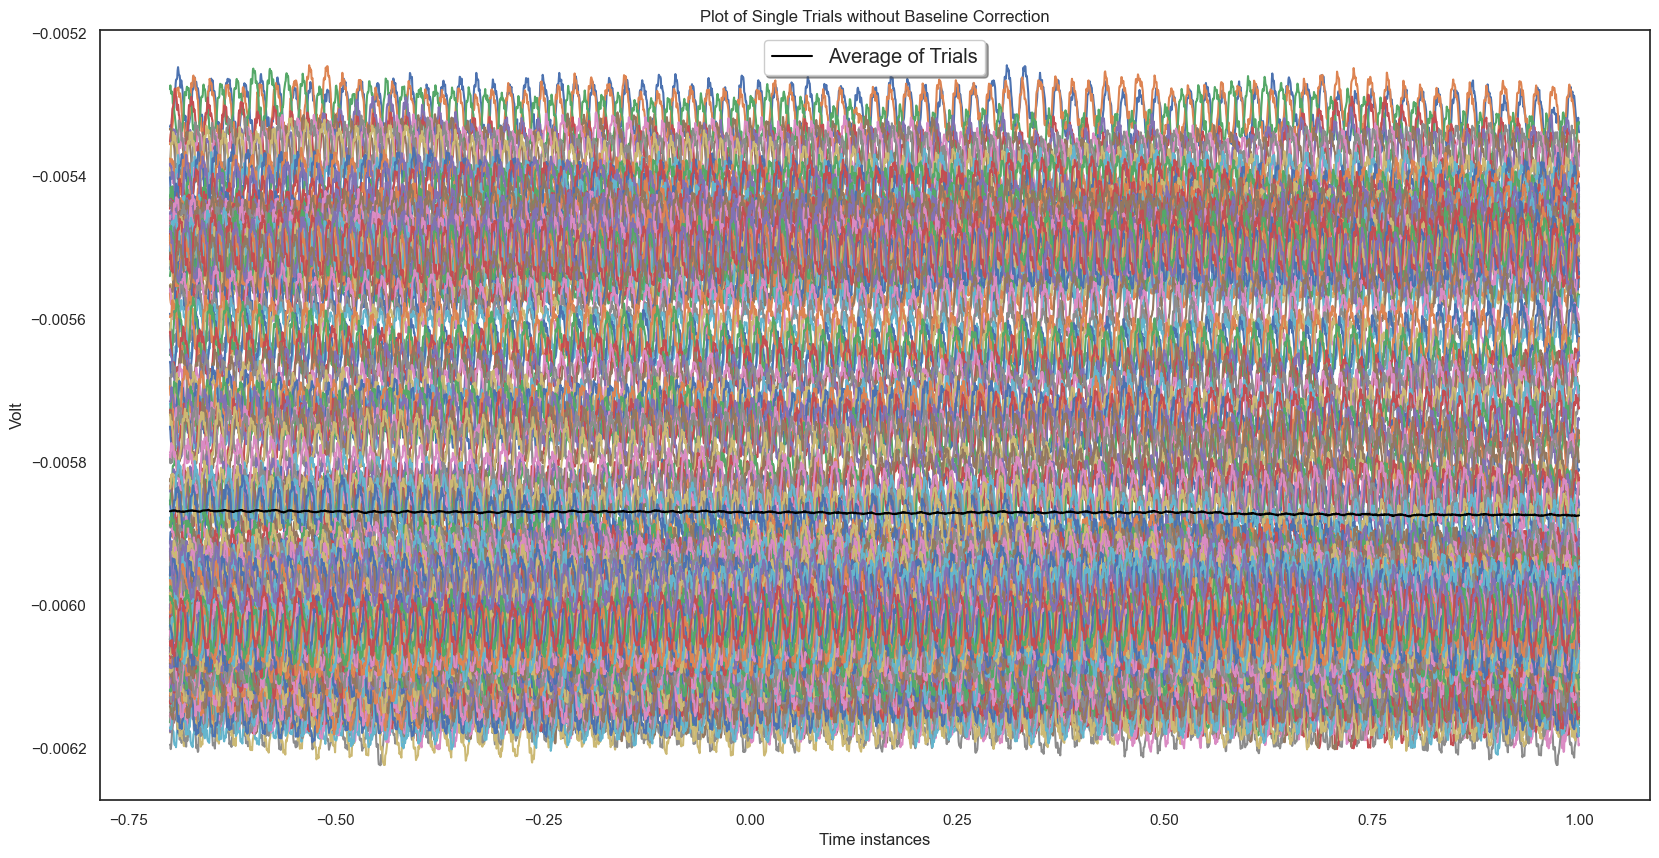

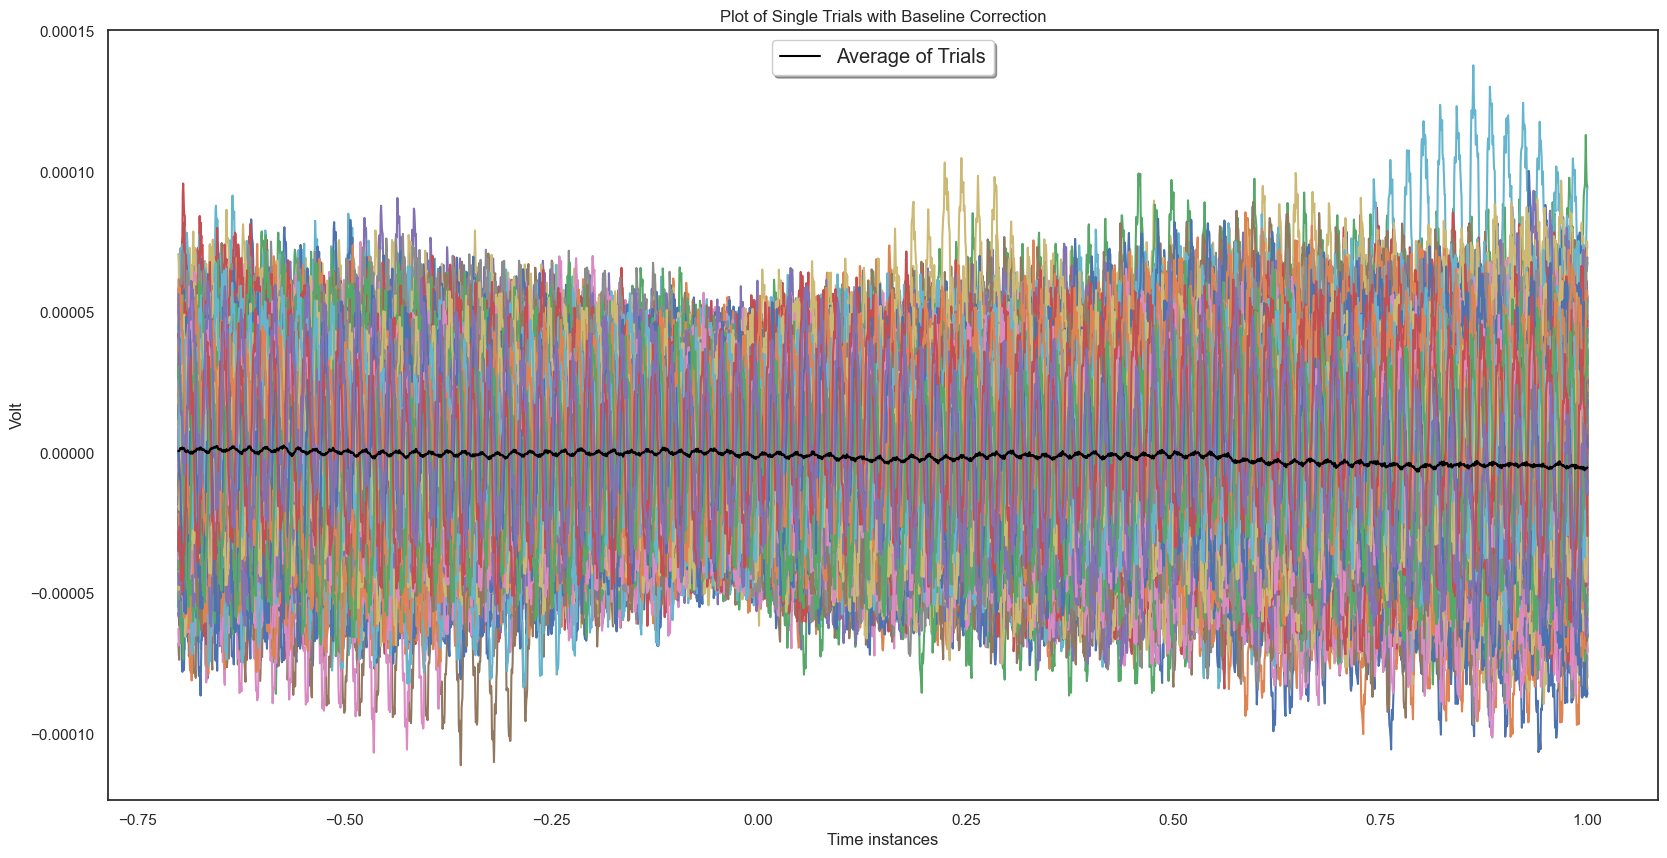

In [29]:
ch_index = 5
plotChannel(ch_index, bc_epochs, epochs_wo_bc)

## Choosing a Reference

In [ ]:
# EEG recordings are collected by measuring the voltage differences between a 
# part of the brain and the reference point. After collecting the data, 
# the reference can be changed and this process is called re-referencing. 
# If the reference changes, the amplitude of the signal at the channels will 
# differ too. Therefore referencing is very critical for EEG data.

In [ ]:
'''
differences in the responses are decreasing significantly when the reference 
changes. Most of the times, the aim of eeg analysis is to identify changes among
different conditions. So, a wrong reference choice may lead a situation where 
those differences cannot be captured. Therefore, reference selection is one of 
the vital steps during eeg analysis.
'''

In [ ]:
'''
Athough there is no optimal strategy for selecting the reference, 
there are several commonly applied approaches. One way is to compute the average
of potentials at all the channels and use this average potential as the 
reference. The new reference does not have to be an existing channel, it can 
be a virtual one as well. After subtracting the averaged potential from 
electrical potential at each channel, re-referencing would be completed. 
Another approach would be to select the channels where electrical activity is 
the lowest such as ears.

Apart from the commonly used approaches above, there are several statistical 
approaches to select the reference that perfom the best 
(https://doi.org/10.1016/j.jneumeth.2014.05.008).
'''

In [30]:
# create two copies of original epochs object for further comparison
original_1 = copy.deepcopy(epochs)
original_2 = copy.deepcopy(epochs)

In [31]:
# Re-reference by averaging
re_ref_epochs = original_1.set_eeg_reference('average', projection=True)

EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.


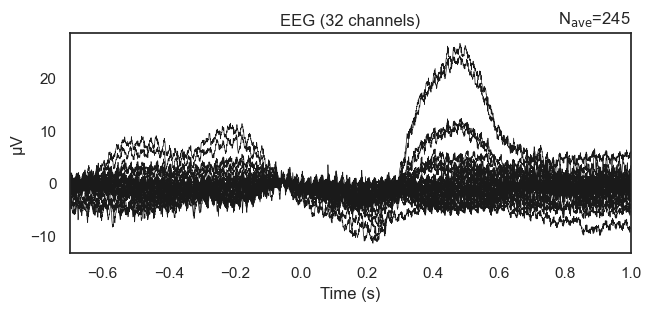

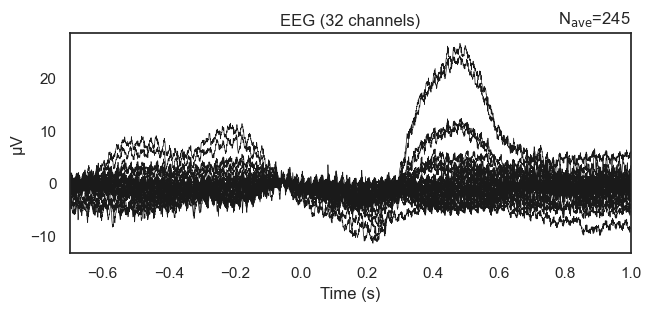

In [32]:
re_ref_epochs.average().plot()

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


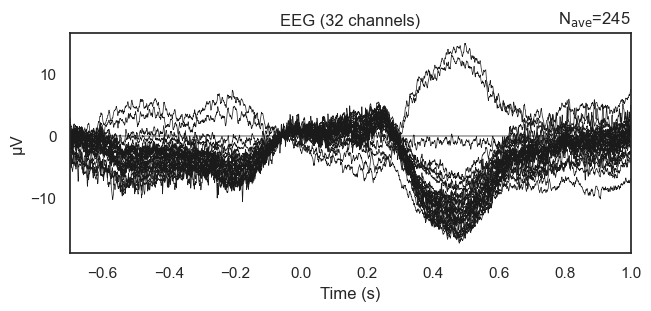

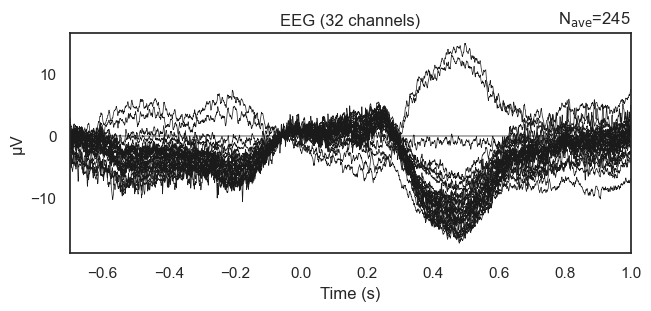

In [34]:
# Set a channel as the new reference
re_ref_epochs_2 = original_2.set_eeg_reference(['AF3'])
re_ref_epochs_2.average().plot()

In [35]:
references = ['original', 'AF3']

#Data with original reference
st = epochs['Standard']
nv = epochs['Novel']

#Data with TP8 as the reference channel
st_2 = original_2['Standard']
nv_2 = original_2['Novel']
ch = 18 # channel index

for i in range(len(references)):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_xlabel('Time Instances')
    ax.set_ylabel('Volt') 
    if references[i] == 'original': 
        plt.title('ERP values of novel and standard conditions with original reference')
        ax.plot(st.average().data[ch,:], color='blue')
        ax.plot(nv.average().data[ch,:], color='red')
    
    else:
        plt.title('ERP values of novel and standard conditions with TP8 channel as reference')
        ax.plot(st_2.average().data[ch,:], color='blue')
        ax.plot(nv_2.average().data[ch,:], color='red')

    plt.show()

KeyError: 'Event name "Standard" could not be found. The following events are present in the data: 1, 2, 4, 8, 9, 10, 16, 25, 32, 64, 73, 128, 65536'

In [38]:
#Effects of Re-referencing on Topography
times = np.arange(-0.1, 0.5, 0.1)
epochs.average().plot_topomap(times, ch_type='eeg')

RuntimeError: No digitization points found.

In [39]:
re_ref_epochs_2.average().plot_topomap(times, ch_type='eeg')

RuntimeError: No digitization points found.